In [1]:
import pandas as pd

file_path = 'base_anonimizada/df_fam_pes_sexo_conj.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,SEXO_CONJUGE
0,1,1596.0,2,11,1401,0,3,1,1,2,...,0.333333,0.333333,0.0,0,0,0.0,0.0,0.00,0.0,1
1,2,309.0,2,11,205,0,2,1,2,1,...,0.000000,0.000000,0.0,0,0,0.0,0.0,0.50,0.0,3
2,3,584.0,2,11,205,0,4,1,1,1,...,0.000000,0.000000,0.0,0,0,0.0,0.0,0.25,0.0,2
3,4,688.0,2,11,1203,0,5,1,1,1,...,0.000000,0.000000,0.2,0,0,0.0,0.0,0.40,0.0,2
4,5,1201.0,2,11,23,0,2,1,1,1,...,0.000000,0.000000,0.0,0,0,0.5,0.0,0.00,0.0,3


In [2]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [3]:
import numpy as np

# Definir condições
condicoes = [
    df['VL_RENDA_MEDIA_FAM'] <= 218,                      # 0 - pobreza
    (df['VL_RENDA_MEDIA_FAM'] > 218) & (df['VL_RENDA_MEDIA_FAM'] <= 759),  # 1 - baixa renda
    df['VL_RENDA_MEDIA_FAM'] > 759                       # 2 - acima de 1/2 salário mínimo
]

# Valores correspondentes
valores = [0, 1, 2]

# Criar a nova coluna
df['classe_renda'] = np.select(condicoes, valores)



In [4]:
df.groupby('classe_renda')['ID_FAM_ANON'].nunique()


classe_renda
0    1054841
1    2521165
2    4497806
Name: ID_FAM_ANON, dtype: int64

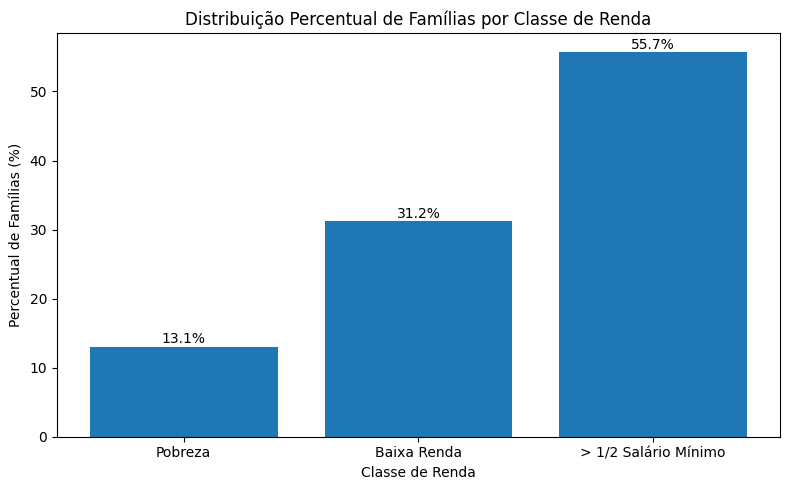

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Contar famílias únicas por classe de renda
familias_por_classe = (
    df.groupby('classe_renda')['ID_FAM_ANON']
      .nunique()
      .reset_index(name='qt_familias')
)

# 2) Calcular percentuais
total_familias = familias_por_classe['qt_familias'].sum()
familias_por_classe['percentual'] = (
    familias_por_classe['qt_familias'] / total_familias * 100
)

# 3) Criar gráfico
plt.figure(figsize=(8,5))
plt.bar(
    familias_por_classe['classe_renda'],
    familias_por_classe['percentual']
)

# Rótulos e formatação
plt.xlabel("Classe de Renda")
plt.ylabel("Percentual de Famílias (%)")
plt.title("Distribuição Percentual de Famílias por Classe de Renda")
plt.xticks([0,1,2], ["Pobreza", "Baixa Renda", "> 1/2 Salário Mínimo"])

# Mostrar valores no topo das barras
for i, v in enumerate(familias_por_classe['percentual']):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()



In [6]:
# Variável-alvo binária para o modelo (triagem)
# 0 = até 1/2 salário mínimo 
# 1 = proxy de renda provável acima do limiar, usada para identificar potenciais inconsistências

df['y_bin'] = np.where(
    df['VL_RENDA_MEDIA_FAM'] > 759,
    1,
    0
)


In [7]:
df['classe_risco_qualificacao'] = np.where(
    df['y_bin'] == 1,
    'renda formal per capita (CNIS) > ½ SM',
    'renda formal per capita (CNIS) ≤ ½ SM'
)


In [8]:
df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,PCT_PES_ANALFABETA,PCT_ADULTO_NUNCA_FREQ_ESCOLA,PCT_7A18_ESCOLA_PUBLICA,PCT_MENOR6_FORA_CRECHE_PRE,SEXO_CONJUGE,classe_renda,y_bin,classe_risco_qualificacao
0,1,1596.0,2,11,1401,0,3,1,1,2,...,0,0,0.0,0.0,0.00,0.0,1,2,1,renda formal per capita (CNIS) > ½ SM
1,2,309.0,2,11,205,0,2,1,2,1,...,0,0,0.0,0.0,0.50,0.0,3,1,0,renda formal per capita (CNIS) ≤ ½ SM
2,3,584.0,2,11,205,0,4,1,1,1,...,0,0,0.0,0.0,0.25,0.0,2,1,0,renda formal per capita (CNIS) ≤ ½ SM
3,4,688.0,2,11,1203,0,5,1,1,1,...,0,0,0.0,0.0,0.40,0.0,2,1,0,renda formal per capita (CNIS) ≤ ½ SM
4,5,1201.0,2,11,23,0,2,1,1,1,...,0,0,0.5,0.0,0.00,0.0,3,2,1,renda formal per capita (CNIS) > ½ SM


In [9]:
df.shape

(8073812, 55)

In [10]:
df.columns

Index(['ID_FAM_ANON', 'VL_RENDA_MEDIA_FAM', 'IN_TRABALHO_INFANTIL_FAM',
       'CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM',
       'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM',
       'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_INDIGENA_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM',
       'IN_PARC_MDS_FAM', 'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
       'IDADE_REFERENCIA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_

In [11]:
import pandas as pd
import numpy as np

# ── Configurações ─────────────────────────────────────────────────────────────
N    = 1_000_000
SEED = 42

PROP_COMPOSICAO = {
    "Outra"       : 0.255,
    "RF_feminino" : 0.142,
    "RF_masculino": 0.022,
    "Casal"       : 0.581,
}

# ------------------------------------------------------------
# 0) Checagens
# ------------------------------------------------------------
cols_necessarias = [
    "classe_renda", "y_bin", "classe_risco_qualificacao",
    "QTD_PESSOAS", "CO_SEXO_PESSOA", "SEXO_CONJUGE", "CO_MUNIC_IBGE_2_FAM"
]
faltantes = [c for c in cols_necessarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltam colunas no df: {faltantes}")

# ------------------------------------------------------------
# 1) Classificar composição familiar
# ------------------------------------------------------------
mask_outra        = df["QTD_PESSOAS"] == 1
mask_rf_feminino  = (df["QTD_PESSOAS"] > 1) & (df["CO_SEXO_PESSOA"] == 2.0) & (df["SEXO_CONJUGE"] == 3)
mask_rf_masculino = (df["QTD_PESSOAS"] > 1) & (df["CO_SEXO_PESSOA"] == 1.0) & (df["SEXO_CONJUGE"] == 3)
mask_casal        = (df["QTD_PESSOAS"] > 1) & (df["SEXO_CONJUGE"] != 3)

df = df.copy()
df["composicao_familiar"] = np.select(
    [mask_outra, mask_rf_feminino, mask_rf_masculino, mask_casal],
    ["Outra", "RF_feminino", "RF_masculino", "Casal"],
    default="Indefinido"
)

# ------------------------------------------------------------
# 2) Garantir representação mínima de cada UF
#    Reservar pelo menos 1 linha por (UF × y_bin × composição) se existir,
#    com mínimo absoluto de MIN_POR_UF linhas por UF no total
# ------------------------------------------------------------
MIN_POR_UF = 100  # mínimo de linhas por UF na amostra final

ufs = sorted(df["CO_MUNIC_IBGE_2_FAM"].dropna().astype(int).unique().tolist())
print(f"UFs presentes no df original ({len(ufs)}): {ufs}")

# Reservar amostra mínima por UF (proporcional à composição e y_bin dentro da UF)
reserva = []
for uf in ufs:
    df_uf = df[df["CO_MUNIC_IBGE_2_FAM"] == uf]
    n_uf  = max(MIN_POR_UF, 0)
    if len(df_uf) == 0:
        continue
    n_amostrar = min(n_uf, len(df_uf))
    reserva.append(
        df_uf.sample(n=n_amostrar, random_state=SEED)
    )

df_reserva   = pd.concat(reserva, axis=0)
idx_reserva  = set(df_reserva.index)
df_restante  = df[~df.index.isin(idx_reserva)]

N_restante = N - len(df_reserva)
print(f"\nReserva mínima por UF: {len(df_reserva):,} linhas ({len(ufs)} UFs × ~{MIN_POR_UF})")
print(f"N restante para amostragem proporcional: {N_restante:,}")

# ------------------------------------------------------------
# 3) Distribuições na base original
# ------------------------------------------------------------
print("\nDistribuição de classe_renda (0/1/2):")
print(df["classe_renda"].value_counts(dropna=False).sort_index())
print("\nDistribuição de y_bin (0/1):")
print(df["y_bin"].value_counts(dropna=False).sort_index())
print("\nDistribuição de composicao_familiar:")
print(df["composicao_familiar"].value_counts(dropna=False))

# ------------------------------------------------------------
# 4) Calcular n alvo por (y_bin × composição) no restante
# ------------------------------------------------------------
prop_y = df_restante["y_bin"].value_counts(normalize=True).sort_index()

n_alvo = {}
for yval, py in prop_y.items():
    for comp, pc in PROP_COMPOSICAO.items():
        n_alvo[(yval, comp)] = py * pc * N_restante

n_alvo_int = {k: int(round(v)) for k, v in n_alvo.items()}
diferenca  = N_restante - sum(n_alvo_int.values())
if diferenca != 0:
    chaves_ord = sorted(n_alvo.keys(), key=lambda k: n_alvo[k], reverse=True)
    passo = 1 if diferenca > 0 else -1
    for i in range(abs(diferenca)):
        n_alvo_int[chaves_ord[i % len(chaves_ord)]] += passo

print("\nN alvo por (y_bin, composição) — base restante:")
for k, v in sorted(n_alvo_int.items()):
    print(f"  y_bin={k[0]}, {k[1]}: {v:,}")
print(f"  TOTAL restante: {sum(n_alvo_int.values()):,}")

# ------------------------------------------------------------
# 5) Verificar disponibilidade no restante
# ------------------------------------------------------------
for (yval, comp), n_req in n_alvo_int.items():
    n_disp = ((df_restante["y_bin"] == yval) & (df_restante["composicao_familiar"] == comp)).sum()
    if n_disp < n_req:
        raise ValueError(
            f"Linhas insuficientes para y_bin={yval}, composição={comp}: "
            f"disponível={n_disp:,}, solicitado={n_req:,}"
        )

# ------------------------------------------------------------
# 6) Amostragem proporcional no restante
# ------------------------------------------------------------
amostras = []
for i, ((yval, comp), n_req) in enumerate(sorted(n_alvo_int.items())):
    subset = df_restante[
        (df_restante["y_bin"] == yval) &
        (df_restante["composicao_familiar"] == comp)
    ]
    amostras.append(subset.sample(n=n_req, random_state=SEED + 100 + i))

df_prop_binario = (
    pd.concat([df_reserva] + amostras, axis=0)
      .sample(frac=1, random_state=SEED + 999)
      .reset_index(drop=True)
)

# ------------------------------------------------------------
# 7) Distribuições na amostra final
# ------------------------------------------------------------
print("\n=== AMOSTRA FINAL (df_prop_binario) ===")
print(f"Shape: {df_prop_binario.shape}")

print("\nDistribuição de y_bin:")
print(df_prop_binario["y_bin"].value_counts(dropna=False).sort_index())

print("\nDistribuição de composicao_familiar (%):")
vc_comp = df_prop_binario["composicao_familiar"].value_counts(dropna=False)
print((vc_comp / len(df_prop_binario) * 100).round(1))

ufs_amostra = sorted(df_prop_binario["CO_MUNIC_IBGE_2_FAM"].dropna().astype(int).unique().tolist())
print(f"\nUFs presentes na amostra ({len(ufs_amostra)}): {ufs_amostra}")

ufs_perdidas = set(ufs) - set(ufs_amostra)
print(f"UFs perdidas: {sorted(ufs_perdidas) if ufs_perdidas else 'Nenhuma — todas preservadas ✓'}")

print("\nCrosstab: composicao_familiar x y_bin:")
print(pd.crosstab(df_prop_binario["composicao_familiar"], df_prop_binario["y_bin"], dropna=False))
print("\nCrosstab: classe_renda x y_bin:")
print(pd.crosstab(df_prop_binario["classe_renda"], df_prop_binario["y_bin"], dropna=False))

UFs presentes no df original (27): [11, 12, 13, 14, 15, 16, 17, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 35, 41, 42, 43, 50, 51, 52, 53]

Reserva mínima por UF: 2,700 linhas (27 UFs × ~100)
N restante para amostragem proporcional: 997,300

Distribuição de classe_renda (0/1/2):
classe_renda
0    1054841
1    2521165
2    4497806
Name: count, dtype: int64

Distribuição de y_bin (0/1):
y_bin
0    3576006
1    4497806
Name: count, dtype: int64

Distribuição de composicao_familiar:
composicao_familiar
RF_feminino     3472930
Casal           2938659
Outra           1363598
RF_masculino     298625
Name: count, dtype: int64

N alvo por (y_bin, composição) — base restante:
  y_bin=0, Casal: 256,634
  y_bin=0, Outra: 112,636
  y_bin=0, RF_feminino: 62,723
  y_bin=0, RF_masculino: 9,718
  y_bin=1, Casal: 322,797
  y_bin=1, Outra: 141,675
  y_bin=1, RF_feminino: 78,894
  y_bin=1, RF_masculino: 12,223
  TOTAL restante: 997,300

=== AMOSTRA FINAL (df_prop_binario) ===
Shape: (1000000, 56)

Di

In [12]:
# Salvar amostra proporcional
df_prop_binario_comp_fam = df_prop_binario.to_csv("df_prop_binario_comp_fam.csv", index=False, encoding="utf-8")